In this notebook, we perform transfer learning on a ResNet101 model using the ImageNet dataset with different masking strategies (with or without) and datasets (full image vs. bounding box). We evaluate the model's performance, compare results across different datasets, and visualize the learning evolution (training and validation accuracy) over time to assess the impact of masking on learning efficiency and robustness.

In [ ]:
import retinoto_py as fovea
model_name = 'resnet101'
args = fovea.Params(do_fovea=False, do_mask=True, model_name=model_name, num_epochs=10)
args

Params(batch_size=128, num_workers=0, prefetch_factor=0, image_size=224, grid_size_ecc=161, grid_size_ang=309, do_mask=True, do_fovea=False, use_hexagonal_grid=True, rs_min=-3.5, rs_max=0.7, angle_start=-5.235987755982989, angle_margin=0.010166966516471823, mode='bilinear', padding_mode='zeros', model_name='resnet101', num_epochs=40, subset_factor=1, optimizer_name='adamw', loss_name='CrossEntropyLoss', base_lr=1e-06, final_lr=1e-09, num_warmup_epochs=20, delta1=0.3, delta2=0.002, weight_decay=0.0001, label_smoothing=0.0005, do_full_training=True, do_augment=True, augment_proba=0.85, stochastic_depth_prob=0.6, seed=1998, shuffle=True, verbose=False)

# transfer learning of each network on the  masked dataset

In [2]:
%ls -ltr cached_data/20*

-rw-r--r--@ 1 laurent  staff  535512069  8 mai   03:45 cached_data/20_model_name=resnet101_dataset=full.pth
-rw-r--r--@ 1 laurent  staff       7706  8 mai   03:45 cached_data/20_model_name=resnet101_dataset=full.json
-rw-r--r--@ 1 laurent  staff  535512069 13 mai   09:36 cached_data/20_model_name=resnet101_dataset=bbox.pth
-rw-r--r--@ 1 laurent  staff       7639 13 mai   09:36 cached_data/20_model_name=resnet101_dataset=bbox.json


In [3]:
# %rm "cached_data/20_model_name=convnext_base_dataset=bbox.lock"   # FORCING RECOMPUTE
# %rm cached_data/20_*.lock   # FORCING RECOMPUTE
# %rm "cached_data/20_model_name=convnext_base_dataset=bbox.lock"   # FORCING RECOMPUTE
# %rm cached_data/20*

In [4]:
for dataset in fovea.params.all_datasets:
    name = f'20_model_name={model_name}_dataset={dataset}'
    model_filename, json_filename = fovea.do_learning(args, dataset, name)

Load JSON from pre-trained resnet cached_data/20_model_name=resnet101_dataset=full.json
cached_data/20_model_name=resnet101_dataset=full.pth: latest accuracy = 0.786
Load JSON from pre-trained resnet cached_data/20_model_name=resnet101_dataset=bbox.json
cached_data/20_model_name=resnet101_dataset=bbox.pth: latest accuracy = 0.799


## Plot learning evolution

This section visualizes the learning process by plotting the training and validation accuracy as a function of the total number of images processed. A rolling mean is applied to smooth the accuracy curves for better visualization.

Load JSON from pre-trained resnet cached_data/20_model_name=resnet101_dataset=full.json
cached_data/20_model_name=resnet101_dataset=full.pth: latest accuracy = 0.786
Load JSON from pre-trained resnet cached_data/20_model_name=resnet101_dataset=bbox.json
cached_data/20_model_name=resnet101_dataset=bbox.pth: latest accuracy = 0.799


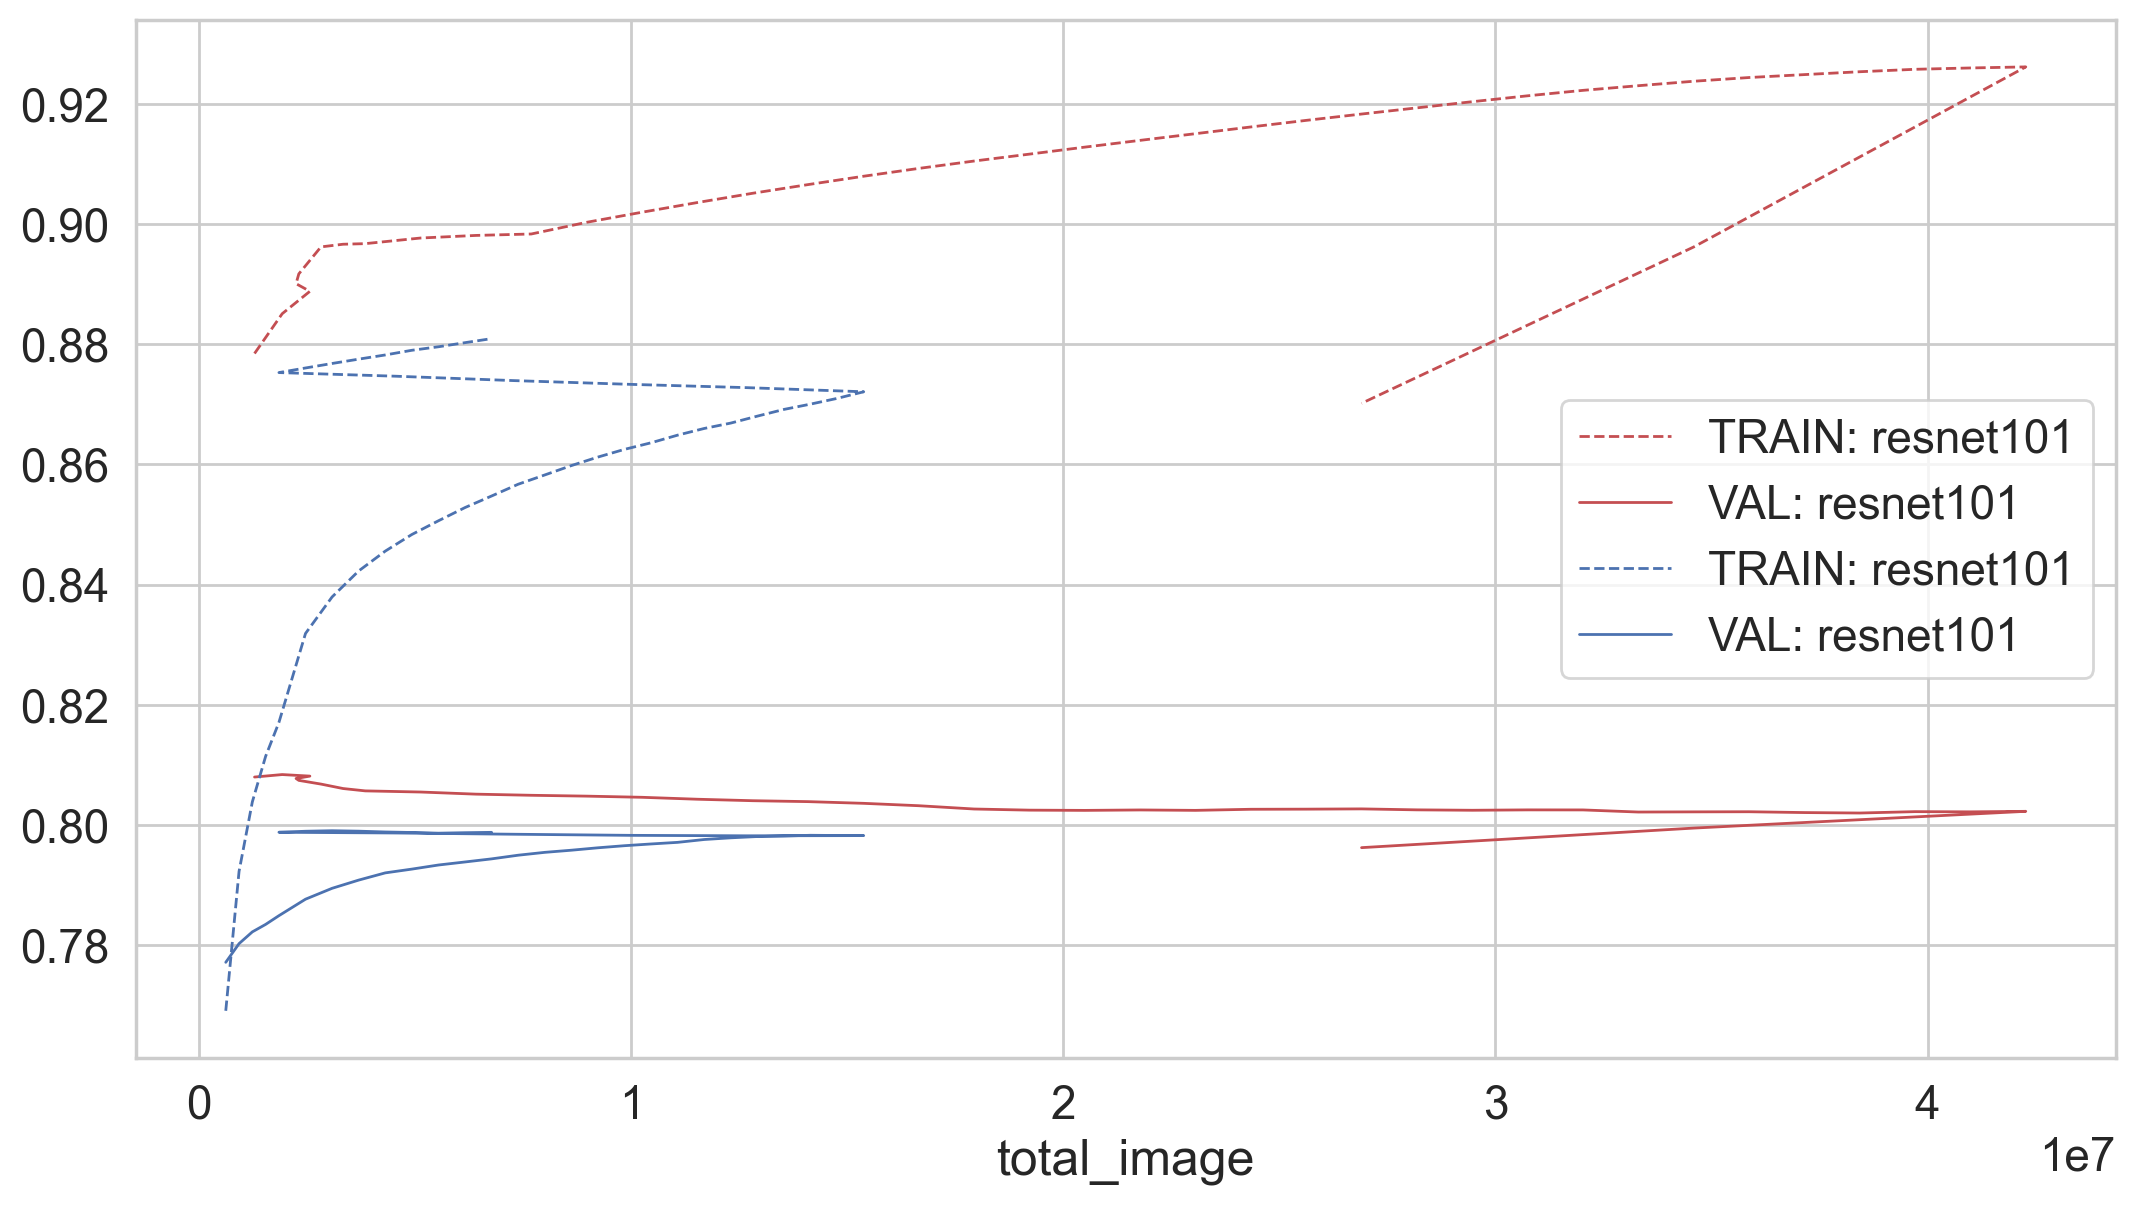

In [5]:
fig, ax = fovea.plt.subplots()
for dataset, color in zip(fovea.params.all_datasets, ['r', 'b']):
    lw = 1

    name = f'20_model_name={model_name}_dataset={dataset}'
    model_filename, json_filename = fovea.do_learning(args, dataset, name)

    df_train = fovea.pd.read_json(json_filename, orient='records')

    df_train_roll = df_train.rolling(window=5, min_periods=1, center=False).mean()
    ax = df_train_roll.plot(x='total_image', y='acc_train', 
                        c=color, ls='dashed', lw=lw,
                        grid=True, ax=ax, label='TRAIN: ' + args.model_name)    
    ax = df_train_roll.plot(x='total_image', y='acc_val', 
                        c=color, lw=lw,
                        grid=True, ax=ax, label='VAL: ' + args.model_name)   

## Model comparison

In this section, we compare the final validation accuracy of the ResNet101 model across the different datasets (full image vs. bounding box) by reading the cached JSON results and comparing them with other baseline models.

In [6]:
for dataset in fovea.params.all_datasets:
    results = fovea.pd.read_json(args.data_cache / f'20_model_name={model_name}_dataset={dataset}.json')
    print(model_name, dataset, results.tail(1)['acc_val'])

resnet101 full 39    0.785637
Name: acc_val, dtype: float64
resnet101 bbox 39    0.79904
Name: acc_val, dtype: float64


In [7]:
results_13 = fovea.pd.read_json(args.data_cache / '13_model_comparison.json')
results_13

,model_name,do_mask,dataset,accuracy,wall_clock_time,total_parameters,trainable_parameters,total_layers
0,resnet18,True,full,0.278955,0.002772,11689512,11689512,68
1,resnet50,True,full,0.698635,0.004663,25557032,25557032,151
2,resnet101,True,full,0.716213,0.006339,44549160,44549160,287
3,resnet18,True,bbox,0.242897,0.001938,11689512,11689512,68
4,resnet50,True,bbox,0.620086,0.003922,25557032,25557032,151
5,resnet101,True,bbox,0.652344,0.006471,44549160,44549160,287
6,resnet18,False,full,0.048989,0.002321,11689512,11689512,68
7,resnet50,False,full,0.104623,0.004325,25557032,25557032,151
8,resnet101,False,full,0.117912,0.005978,44549160,44549160,287
9,resnet18,False,bbox,0.042969,0.001733,11689512,11689512,68
